In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

X = np.load('../data/features/X_counts_full.npy')
y = np.load('../data/features/y_full.npy')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
X_train_normal = X_train[y_train == 0]

rng = np.random.default_rng(42)
lof_idx = rng.choice(len(X_train_normal), size=50_000, replace=False)

In [2]:
scores = {}

model = IsolationForest(contamination=0.03, random_state=42)
model.fit(X_train_normal)
scores['Isolation Forest'] = -model.score_samples(X_test)

model = LocalOutlierFactor(n_neighbors=20, contamination=0.03, novelty=True)
model.fit(X_train_normal[lof_idx])
scores['Local Outlier Factor'] = -model.score_samples(X_test)

model = PCA(n_components=5, random_state=42)
model.fit(X_train_normal)
reconstructed = model.inverse_transform(model.transform(X_test))
scores['PCA'] = np.mean((X_test - reconstructed) ** 2, axis=1)

model = RandomForestClassifier(n_estimators=100, random_state=42,
                               class_weight='balanced')
model.fit(X_train, y_train)
scores['Random Forest'] = model.predict_proba(X_test)[:, 1]

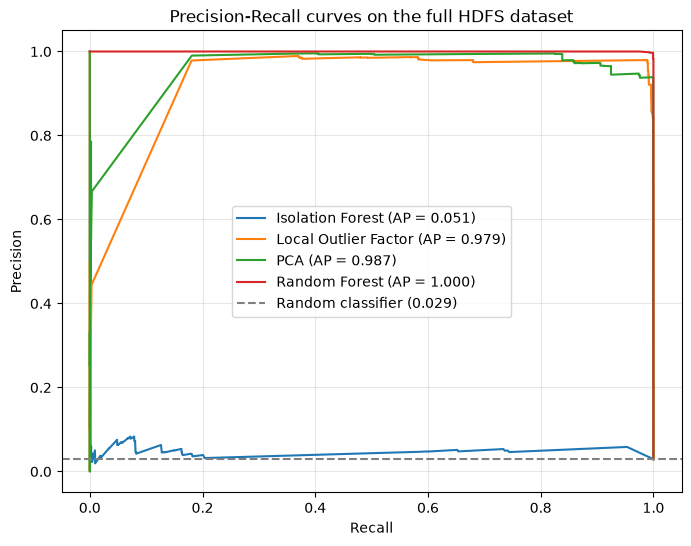

In [3]:
plt.figure(figsize=(8, 6))

for name, score in scores.items():
    precision, recall, _ = precision_recall_curve(y_test, score)
    ap = average_precision_score(y_test, score)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')

baseline = y_test.mean()
plt.axhline(baseline, linestyle='--', color='gray',
            label=f'Random classifier ({baseline:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curves on the full HDFS dataset')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../results/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()